In [1]:
import re
import datetime
import pathlib
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
VERSION = datetime.datetime.now().strftime("%y%m%d")
print(f"Execute Date: {VERSION}")

Execute Date: 260324


## Parameters for papermill

In [3]:
foldseek_result_tsv = pathlib.Path("../test/oryza_sativa_test_100genes_202603/foldseek_output_human_proteome_v6_os_100_genes_9606.tsv")
query_uniprot_idmapping_tsv = pathlib.Path("../test/oryza_sativa_test_100genes_202603/os_100_genes_idmapping_all.tsv")
water_result_dir_path = pathlib.Path("../test/oryza_sativa_test_100genes_202603/result_water")
needle_result_dir_path = pathlib.Path("../test/oryza_sativa_test_100genes_202603/result_needle")
query_gene_list_tsv_path = pathlib.Path("../test/oryza_sativa_test_100genes_202603/oryza_sativa_random_100genes_list.tsv")
togoid_convert_tsv_path = pathlib.Path("../test/oryza_sativa_test_100genes_202603/foldseek_target_species_togoid_convert.tsv")

In [4]:
# Parameters
foldseek_result_tsv = "/tmp/tkbjs2zl/stgfdf87100-0fd2-4abe-b4cf-e0526122da93/foldseek_os_random_9606.tsv"
query_uniprot_idmapping_tsv = "/tmp/tkbjs2zl/stg764caa78-3cfd-4c41-adcd-f550e7717c39/sl_100_genes_idmapping_all.tsv"
water_result_dir_path = "/tmp/tkbjs2zl/stg1cc82931-ab1f-40bd-8d5a-ffd60b1163dc/result_water"
needle_result_dir_path = "/tmp/tkbjs2zl/stgbf0e1f1c-96a4-49d4-9372-6f3214de69d1/result_needle"
query_gene_list_tsv_path = "/tmp/tkbjs2zl/stgdcba1535-73fc-453a-9a38-a08639934adb/solanum_lycopersicum_random_100genes_list.tsv"
togoid_convert_tsv_path = "/tmp/tkbjs2zl/stgc51ac6f0-f473-4278-941f-8e4e3364df20/foldseek_hit_species_togoid_convert.tsv"


&nbsp;

&nbsp;

&nbsp;

## (1) Foldseek (Structural Alignment) Result

- Foldseek version: [10-941cd33](https://github.com/steineggerlab/foldseek/releases/tag/10-941cd33)
- About Column name: [foldseek GitHub page](https://github.com/steineggerlab/foldseek?tab=readme-ov-file#output-search)
- In this workflow, foldseek alignment type is `TM-align` (default). So, `e-value` column means `(qTMscore+tTMscore) / 2`
- More details: [TM-align Alignment mode](https://github.com/steineggerlab/foldseek?tab=readme-ov-file#alignment-mode)

&nbsp;

### About Hit Pairs

- In this analysis workflow, the results are output with multiple hits remaining for a single query UniProt ID (protein structure).

&nbsp;

In [5]:
foldseek_result_df = pl.read_csv(
    foldseek_result_tsv,
    separator='\t'
).with_columns(
    (pl.col("UniProt Accession").str.extract(r"AF-(.*?)-F1", 1).alias("UniProt Accession")), # "?" means non-greedy
    (pl.col("foldseek hit").str.extract(r"AF-(.*?)-F1", 1).alias("foldseek hit"))
)

foldseek_result = pl.read_csv(
    query_uniprot_idmapping_tsv, # query idmapping
    separator='\t'
).join(
    foldseek_result_df,
    on="UniProt Accession",
    how="inner",
    coalesce=True
)

display(foldseek_result)

From,UniProt Accession,foldseek hit,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,qcov,tcov,lddt,qtmscore,ttmscore,alntmscore,rmsd,qaln,taln,mismatch,lddtfull
str,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,str,str,i64,str
"""Solyc07g053320.3""","""A0A3Q7HBX7""","""Q9UBW5""",0.1916,0.034,29,1.1,0.011,8,1,359,435,28,523,565,717,0.825,0.878,0.5579,0.2221,0.1787,0.2582,6.626,"""M--DLK---S------ISW---VGNI-YQK…","""VLQKLGKAVETKDERF--EQSA--SNF-YQ…",130,"""0.208,0.341,0.275,0.232,0.225,…"
"""Solyc07g053320.3""","""A0A3Q7HBX7""","""Q14814""",0.1681,0.016,34,1.6,0.016,11,8,391,435,4,413,521,659,0.883,0.787,0.5388,0.1903,0.1675,0.2092,7.454,"""W-VGNIYQKFE-TMCLEMEE--A-------…","""KK-IQIQRITDERNRQVTFTKRKFGLMKKA…",124,"""0.067,0.202,0.208,0.233,0.250,…"
"""Solyc07g053320.3""","""A0A3Q7HBX7""","""Q02078""",0.1627,0.016,25,0.7,0.007,5,24,382,435,30,505,507,712,0.825,0.939,0.5004,0.1828,0.1622,0.21,7.069,"""EEAMYQFG--NVTRW------------NLL…","""KKAYELSVLCDCEIALIIFNSSNKLFQYAS…",118,"""0.250,0.350,0.243,0.280,0.380,…"
"""Solyc07g053320.3""","""A0A3Q7HBX7""","""Q06413""",0.1597,0.014,28,0.7,0.007,5,23,425,435,29,463,473,714,0.926,0.92,0.5286,0.1747,0.1658,0.1845,7.559,"""MEEAMYQFGNVTRWN---------------…","""MKKAYELSVLCDCEIALIIFNSTNKLFQYA…",119,"""0.250,0.305,0.430,0.324,0.341,…"
"""Solyc07g053320.3""","""A0A3Q7HBX7""","""Q02080""",0.1552,0.01,25,0.6,0.006,4,13,421,435,1,365,365,655,0.94,1.0,0.4433,0.1588,0.1785,0.1788,7.943,"""YQKFETMCLE-M--------E--EAMYQFG…","""MGR-KKIQISRILDQRNRQVTFTKRKFGLM…",115,"""0.065,0.136,0.129,0.188,0.220,…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Solyc01g106470.3""","""A0A3Q7ERI3""","""Q9H3M7""",0.1924,0.02,27,1.2,0.012,5,100,410,431,19,249,391,410,0.722,0.591,0.2432,0.1969,0.211,0.303,7.207,"""NK-WEFVDLPIFRVEKGEENGLVERQTLEN…","""KVY-G------------------------S…",127,"""0.154,0.121,0.081,0.189,0.160,…"
"""Solyc01g106470.3""","""A0A3Q7ERI3""","""P08887""",0.1881,0.024,27,0.9,0.009,5,82,417,431,13,326,468,516,0.78,0.671,0.2648,0.2066,0.1936,0.2594,6.816,"""FD----VEVD--------------------…","""LAAPGA-ALAPRRCPAQEVARGVLTSLPGD…",129,"""0.080,0.035,0.090,0.122,0.172,…"
"""Solyc01g106470.3""","""A0A3Q7ERI3""","""P26992""",0.187,0.016,25,1.9,0.019,8,9,303,431,64,299,372,402,0.684,0.634,0.2743,0.19,0.2123,0.2871,7.133,"""CCYLFAIF-ILAIAVW---FS---------…","""LAPDLLNGSQLVLHGLELGHSGLYACFHRD…",121,"""0.333,0.383,0.484,0.422,0.375,…"


&nbsp;

&nbsp;

## (2) Create Scatter Plot for all hits (Strucutural alignment identity vs LDDT)

- Identity in the results of the structural alignment is also output in the foldseek output.
- However, in this notebook, you can also select the results of the pairwise alignment of amino acid sequences (global alignment, local alignment).

&nbsp;

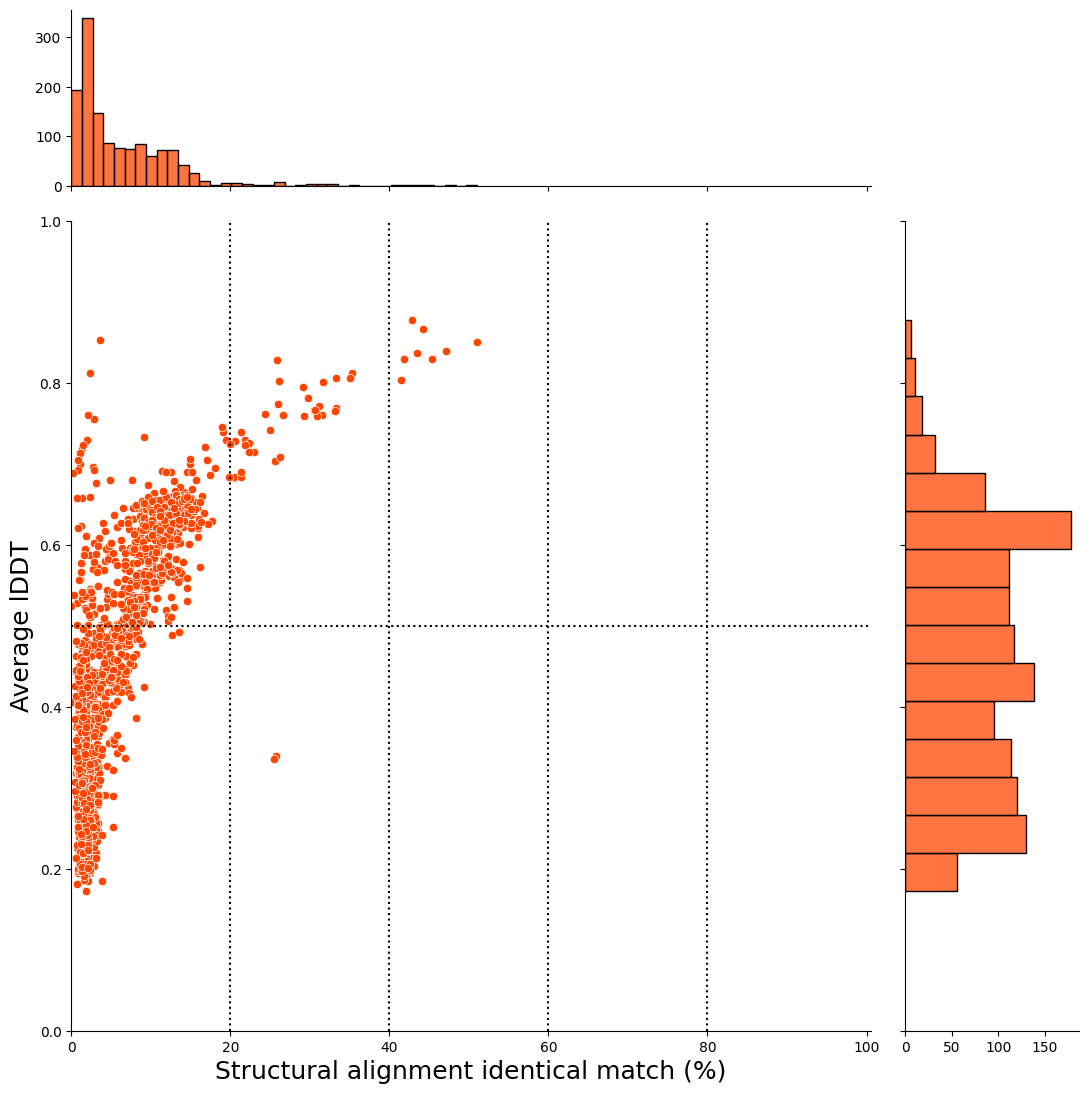

In [6]:
foldseek_filter_viz = foldseek_result.to_pandas()

sns.jointplot(
    data=foldseek_filter_viz,
    x="pident", # structural alignment identical match from foldseek result
    y="lddt",
    color="orangered",
    height=11,
    ratio=4,
    marginal_ticks=True
)

plt.xlim(0,100.5)
plt.ylim(0,1)
plt.xlabel("Structural alignment identical match (%)", fontsize=18)
plt.ylabel("Average lDDT", fontsize=18) # see foldseek github https://github.com/steineggerlab/foldseek?tab=readme-ov-file#output-search
plt.axvline(x=20, color="black", linestyle=":")
plt.axvline(x=40, color="black", linestyle=":")
plt.axvline(x=60, color="black", linestyle=":")
plt.axvline(x=80, color="black", linestyle=":")
plt.axhline(y=0.5, color="black", linestyle=":")

# Save as PNG
plt.savefig(
    "foldseek_result_pident_lddt.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

&nbsp;

&nbsp;

&nbsp;

&nbsp;

## (3) Parse protein sequence pairwise alignment result (water and needle)

- package: EMBOSS:6.5.7--4
- Score Subsutitution Matrix: EBLOSUM30 (For considering remote similarity)
- Website: [EMBOSS](https://emboss.sourceforge.net/)
- needle document: [EMBOSS needle](https://emboss.sourceforge.net/apps/release/6.0/emboss/apps/needle.html)
- water document: [EMBOSS water](https://emboss.sourceforge.net/apps/cvs/emboss/apps/water.html)
- EMBL-EBI Webserver: [EMBOSS NEEDLE](https://www.ebi.ac.uk/jdispatcher/psa/emboss_needle)
- EMBL-EBI Webserver: [EMBOSS WATER](https://www.ebi.ac.uk/jdispatcher/psa/emboss_water)

- For pairs hit by Foldseek (structural alignment), we perform analysis on the sequence similarity observed upon alignment at the `protein sequence level`.
- In other words, it is performing an alignment again on the pair of sequences, not just the regions aligned by Foldseek.

&nbsp;

In [7]:
def parse_needle_water_result(file_path: str | pathlib.Path) -> dict:
    with open(file_path, "r", encoding="utf-8") as file:
        data = file.readlines()

    result = {
        "UniProt Accession": None,
        "foldseek hit": None,
        "Matrix": None,
        "Gap_penalty": None,
        "Extend_penalty": None,
        "Align_Length": None,
        "Identity": None,
        "Identity_percent": None,
        "Similarity": None,
        "Similarity_percent": None,
        "Gaps": None,
        "Gaps_percent": None,
        "Score": None,
        "Longest_Identity": None,
        "Longest_Similarity": None,
        "Shortest_Identity": None,
        "Shortest_Similarity": None,
    }

    for line in data:
        if line.startswith("# 1:"):
            result['UniProt Accession'] = line.split(":")[1].strip()
        elif line.startswith("# 2:"):
            result["foldseek hit"] = line.split(":")[1].strip()
        elif line.startswith("# Matrix:"):
            result["Matrix"] = line.split(":")[1].strip()
        elif line.startswith("# Gap_penalty:"):
            result["Gap_penalty"] = float(line.split(":")[1].strip())
        elif line.startswith("# Extend_penalty:"):
            result["Extend_penalty"] = float(line.split(":")[1].strip())
        elif line.startswith("# Length:"):
            result["Align_Length"] = int(line.split()[2])
        elif line.startswith("# Identity:"):
            result["Identity"] = line.split()[2]
            if m := re.search(r"\((.*?)%\)", line):
                result["Identity_percent"] = float(m.group(1))
        elif line.startswith("# Similarity:"):
            result["Similarity"] = line.split()[2]
            if m := re.search(r"\((.*?)%\)", line):
                result["Similarity_percent"] = float(m.group(1))
        elif line.startswith("# Gaps:"):
            result["Gaps"] = line.split()[2]
            if m := re.search(r"\((.*?)%\)", line):
                result["Gaps_percent"] = float(m.group(1))
        elif line.startswith("# Score:"):
            result["Score"] = float(line.split()[2])
        elif line.startswith("# Longest_Identity"):
            result["Longest_Identity"] = float(
                line.split("=")[1].strip().rstrip("%")
            )
        elif line.startswith("# Longest_Similarity"):
            result["Longest_Similarity"] = float(
                line.split("=")[1].strip().rstrip("%")
            )
        elif line.startswith("# Shortest_Identity"):
            result["Shortest_Identity"] = float(
                line.split("=")[1].strip().rstrip("%")
            )
        elif line.startswith("# Shortest_Similarity"):
            result["Shortest_Similarity"] = float(
                line.split("=")[1].strip().rstrip("%")
            )

    return result

In [8]:
water_result_dir = pathlib.Path(water_result_dir_path)
needle_result_dir = pathlib.Path(needle_result_dir_path)

# Initialize empty lists to store DataFrames
water_dfs = []
needle_dfs = []

# Collect all water results
for result_file in water_result_dir.glob("*_align.water"):
    parsed_data = parse_needle_water_result(result_file)
    water_dfs.append(pl.DataFrame([parsed_data]))

# Collect all needle results    
for result_file in needle_result_dir.glob("*_align.needle"):
    parsed_data = parse_needle_water_result(result_file)
    needle_dfs.append(pl.DataFrame([parsed_data]))

# Combine all results and sort only if there are results
water_result = (pl.concat(water_dfs, how='vertical')
                .sort(["UniProt Accession", "foldseek hit"]) 
                if water_dfs else pl.DataFrame()).with_columns(
                    pl.col("UniProt Accession").str.extract(r"AF-(.*?)-F1", 1).alias("UniProt Accession"), # add removing AF- prefix
                    pl.col("foldseek hit").str.extract(r"AF-(.*?)-F1", 1).alias("foldseek hit") # add removing AF- prefix
                )

needle_result = (pl.concat(needle_dfs, how='vertical')
                 .sort(["UniProt Accession", "foldseek hit"])
                 if needle_dfs else pl.DataFrame()).with_columns(
                    pl.col("UniProt Accession").str.extract(r"AF-(.*?)-F1", 1).alias("UniProt Accession"), # add removing AF- prefix
                    pl.col("foldseek hit").str.extract(r"AF-(.*?)-F1", 1).alias("foldseek hit") # add removing AF- prefix
                )

display(water_result)
display(needle_result)

UniProt Accession,foldseek hit,Matrix,Gap_penalty,Extend_penalty,Align_Length,Identity,Identity_percent,Similarity,Similarity_percent,Gaps,Gaps_percent,Score,Longest_Identity,Longest_Similarity,Shortest_Identity,Shortest_Similarity
str,str,str,f64,f64,i64,str,f64,str,f64,str,f64,f64,f64,f64,f64,f64
"""A0A3Q7E7M7""","""A6NNV3""","""EBLOSUM30""",10.0,0.5,371,"""56/371""",15.1,"""124/371""",33.4,"""132/371""",35.6,193.0,23.43,51.88,13.83,30.62
"""A0A3Q7E7M7""","""O00591""","""EBLOSUM30""",10.0,0.5,497,"""99/497""",19.9,"""181/497""",36.4,"""190/497""",38.2,336.0,32.25,58.96,22.5,41.14
"""A0A3Q7E7M7""","""O95264""","""EBLOSUM30""",10.0,0.5,424,"""81/424""",19.1,"""174/424""",41.0,"""129/424""",30.4,297.0,27.46,58.98,18.37,39.46
"""A0A3Q7E7M7""","""P02708""","""EBLOSUM30""",10.0,0.5,483,"""96/483""",19.9,"""176/483""",36.4,"""184/483""",38.1,327.5,32.11,58.86,21.01,38.51
"""A0A3Q7E7M7""","""P11230""","""EBLOSUM30""",10.0,0.5,528,"""93/528""",17.6,"""182/528""",34.5,"""198/528""",37.5,273.5,28.18,55.15,18.56,36.33
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Q38JE1""","""Q6JVE9""","""EBLOSUM30""",10.0,0.5,190,"""39/190""",20.5,"""70/190""",36.8,"""56/190""",29.5,147.0,29.1,52.24,21.08,37.84
"""Q38JE1""","""Q6UWW0""","""EBLOSUM30""",10.0,0.5,188,"""44/188""",23.4,"""89/188""",47.3,"""36/188""",19.1,201.0,28.95,58.55,23.78,48.11
"""Q38JE1""","""Q9H8M1""","""EBLOSUM30""",10.0,0.5,182,"""34/182""",18.7,"""78/182""",42.9,"""48/182""",26.4,126.0,25.37,58.21,14.29,32.77


UniProt Accession,foldseek hit,Matrix,Gap_penalty,Extend_penalty,Align_Length,Identity,Identity_percent,Similarity,Similarity_percent,Gaps,Gaps_percent,Score,Longest_Identity,Longest_Similarity,Shortest_Identity,Shortest_Similarity
str,str,str,f64,f64,i64,str,f64,str,f64,str,f64,f64,f64,f64,f64,f64
"""A0A3Q7E7M7""","""A6NNV3""","""EBLOSUM30""",10.0,0.5,504,"""58/504""",11.5,"""130/504""",25.8,"""251/504""",49.8,189.5,22.92,51.38,14.32,32.1
"""A0A3Q7E7M7""","""O00591""","""EBLOSUM30""",10.0,0.5,527,"""99/527""",18.8,"""185/527""",35.1,"""209/527""",39.7,333.0,31.13,58.18,22.5,42.05
"""A0A3Q7E7M7""","""O95264""","""EBLOSUM30""",10.0,0.5,543,"""83/543""",15.3,"""177/543""",32.6,"""240/543""",44.2,292.0,27.39,58.42,18.82,40.14
"""A0A3Q7E7M7""","""P02708""","""EBLOSUM30""",10.0,0.5,554,"""96/554""",17.3,"""180/554""",32.5,"""246/554""",44.4,321.0,31.17,58.44,21.01,39.39
"""A0A3Q7E7M7""","""P11230""","""EBLOSUM30""",10.0,0.5,571,"""94/571""",16.5,"""185/571""",32.4,"""236/571""",41.3,258.5,28.06,55.22,18.76,36.93
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Q38JE1""","""Q6JVE9""","""EBLOSUM30""",10.0,0.5,219,"""39/219""",17.8,"""70/219""",32.0,"""78/219""",35.6,146.0,27.66,49.65,21.08,37.84
"""Q38JE1""","""Q6UWW0""","""EBLOSUM30""",10.0,0.5,217,"""44/217""",20.3,"""89/217""",41.0,"""65/217""",30.0,201.0,28.95,58.55,23.78,48.11
"""Q38JE1""","""Q9H8M1""","""EBLOSUM30""",10.0,0.5,276,"""40/276""",14.5,"""87/276""",31.5,"""129/276""",46.7,119.5,27.21,59.18,16.81,36.55


In [9]:
alignment_result = water_result.join(
    needle_result,
    on=["UniProt Accession", "foldseek hit"],
    how="inner",
    coalesce=True,
    suffix="_needle"
).rename(
    {
        "Align_Length": "Align_Length_water",
        "Identity": "Identity_water",
        "Identity_percent": "Identity_percent_water",
        "Similarity": "Similarity_water",
        "Similarity_percent": "Similarity_percent_water",
        "Gaps": "Gaps_water",
        "Gaps_percent": "Gaps_percent_water",
        "Longest_Identity": "Longest_Identity_water",
        "Longest_Similarity": "Longest_Similarity_water",
        "Shortest_Identity": "Shortest_Identity_water",
        "Shortest_Similarity": "Shortest_Similarity_water",
        "Score": "Score_water"
    }
).select(
    [
        "UniProt Accession",
        "foldseek hit",
        "Align_Length_water",
        "Align_Length_needle",
        "Identity_water",
        "Identity_needle",
        "Identity_percent_water",
        "Identity_percent_needle",
        "Similarity_percent_water",
        "Similarity_percent_needle",
        "Gaps_water",
        "Gaps_needle",
        "Gaps_percent_water",
        "Gaps_percent_needle",
        "Shortest_Identity_water",
        "Shortest_Identity_needle",
        "Longest_Identity_water",
        "Longest_Identity_needle",
        "Shortest_Similarity_water",
        "Shortest_Similarity_needle",
        "Longest_Similarity_water",
        "Longest_Similarity_needle",
        "Score_water",
        "Score_needle",
        "Gap_penalty",
        "Extend_penalty",
        "Matrix"
    ]
)

display(alignment_result)

UniProt Accession,foldseek hit,Align_Length_water,Align_Length_needle,Identity_water,Identity_needle,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_needle,Gaps_percent_water,Gaps_percent_needle,Shortest_Identity_water,Shortest_Identity_needle,Longest_Identity_water,Longest_Identity_needle,Shortest_Similarity_water,Shortest_Similarity_needle,Longest_Similarity_water,Longest_Similarity_needle,Score_water,Score_needle,Gap_penalty,Extend_penalty,Matrix
str,str,i64,i64,str,str,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""A0A3Q7E7M7""","""A6NNV3""",371,504,"""56/371""","""58/504""",15.1,11.5,33.4,25.8,"""132/371""","""251/504""",35.6,49.8,13.83,14.32,23.43,22.92,30.62,32.1,51.88,51.38,193.0,189.5,10.0,0.5,"""EBLOSUM30"""
"""A0A3Q7E7M7""","""O00591""",497,527,"""99/497""","""99/527""",19.9,18.8,36.4,35.1,"""190/497""","""209/527""",38.2,39.7,22.5,22.5,32.25,31.13,41.14,42.05,58.96,58.18,336.0,333.0,10.0,0.5,"""EBLOSUM30"""
"""A0A3Q7E7M7""","""O95264""",424,543,"""81/424""","""83/543""",19.1,15.3,41.0,32.6,"""129/424""","""240/543""",30.4,44.2,18.37,18.82,27.46,27.39,39.46,40.14,58.98,58.42,297.0,292.0,10.0,0.5,"""EBLOSUM30"""
"""A0A3Q7E7M7""","""P02708""",483,554,"""96/483""","""96/554""",19.9,17.3,36.4,32.5,"""184/483""","""246/554""",38.1,44.4,21.01,21.01,32.11,31.17,38.51,39.39,58.86,58.44,327.5,321.0,10.0,0.5,"""EBLOSUM30"""
"""A0A3Q7E7M7""","""P11230""",528,571,"""93/528""","""94/571""",17.6,16.5,34.5,32.4,"""198/528""","""236/571""",37.5,41.3,18.56,18.76,28.18,28.06,36.33,36.93,55.15,55.22,273.5,258.5,10.0,0.5,"""EBLOSUM30"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Q38JE1""","""Q6JVE9""",190,219,"""39/190""","""39/219""",20.5,17.8,36.8,32.0,"""56/190""","""78/219""",29.5,35.6,21.08,21.08,29.1,27.66,37.84,37.84,52.24,49.65,147.0,146.0,10.0,0.5,"""EBLOSUM30"""
"""Q38JE1""","""Q6UWW0""",188,217,"""44/188""","""44/217""",23.4,20.3,47.3,41.0,"""36/188""","""65/217""",19.1,30.0,23.78,23.78,28.95,28.95,48.11,48.11,58.55,58.55,201.0,201.0,10.0,0.5,"""EBLOSUM30"""
"""Q38JE1""","""Q9H8M1""",182,276,"""34/182""","""40/276""",18.7,14.5,42.9,31.5,"""48/182""","""129/276""",26.4,46.7,14.29,16.81,25.37,27.21,32.77,36.55,58.21,59.18,126.0,119.5,10.0,0.5,"""EBLOSUM30"""


&nbsp;

&nbsp;

&nbsp;

&nbsp;

## (4) Integrate foldseek result and pairwise alignment result

- This time, **exclude the ones that are null in pairwise alignment result, which means the current UniProt entry is obsolete**

In [10]:
join_foldseek = foldseek_result.join(
    alignment_result,
    on=["UniProt Accession", "foldseek hit"],
    how="left",
    coalesce=True
).filter( # filter out null alignment result (this means current UniProt entry is obsolete)
    pl.col("Align_Length_water").is_not_null() & 
    pl.col("Align_Length_needle").is_not_null()
).unique()

join_foldseek.write_csv(
    "foldseek_result_join_alignment_result_all.tsv",
    separator='\t'
)


display(join_foldseek)

From,UniProt Accession,foldseek hit,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,qcov,tcov,lddt,qtmscore,ttmscore,alntmscore,rmsd,qaln,taln,mismatch,lddtfull,Align_Length_water,Align_Length_needle,Identity_water,Identity_needle,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_needle,Gaps_percent_water,Gaps_percent_needle,Shortest_Identity_water,Shortest_Identity_needle,Longest_Identity_water,Longest_Identity_needle,Shortest_Similarity_water,Shortest_Similarity_needle,Longest_Similarity_water,Longest_Similarity_needle,Score_water,Score_needle,Gap_penalty,Extend_penalty,Matrix
str,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,str,str,i64,str,i64,i64,str,str,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""Solyc12g036793.1""","""A0A3Q7J846""","""Q8N6Y2""",0.4056,0.254,38,3.7,0.037,18,7,360,396,51,437,441,486,0.894,0.878,0.3801,0.4465,0.4099,0.4873,6.091,"""SAVA------------V--LLGPLLPIAVY…","""GLPCDVYTYLHEKYLDCQERKLVYVL--PG…",237,"""0.143,0.226,0.197,0.383,0.380,…",448,524,"""95/448""","""100/524""",21.2,19.1,35.7,32.8,"""156/448""","""211/524""",34.8,40.3,21.54,22.68,32.53,31.95,36.28,39.0,54.79,54.95,333.5,315.5,10.0,0.5,"""EBLOSUM30"""
"""Solyc06g072800.3""","""A0A3Q7GYX0""","""O00212""",0.69,0.941,16,11.9,0.119,25,13,190,193,13,204,210,210,0.922,0.914,0.6373,0.7361,0.6806,0.7973,2.679,"""FGNSEMRVVMLGLDAAGKTTILYKLHIG--…","""PGVRSVKVVLVGDGGCGKTSLLMVFADGAF…",135,"""0.224,0.340,0.518,0.618,0.691,…",208,231,"""46/208""","""47/231""",22.1,20.3,45.7,42.9,"""43/208""","""59/231""",20.7,25.5,21.9,22.38,27.88,27.33,45.24,47.14,57.58,57.56,190.5,187.0,10.0,0.5,"""EBLOSUM30"""
"""Solyc03g112320.3""","""A0A3Q7GEL9""","""Q9UKV5""",0.233,0.04,71,2.0,0.02,20,11,675,699,1,600,643,1013,0.951,0.933,0.2804,0.2369,0.253,0.2663,8.227,"""L-LFLIFAGWLSV-WL--LKP-TQ------…","""MP-LLFLERFPWPS-LRT-YTGLSGLALLG…",232,"""0.081,0.192,0.206,0.183,0.161,…",820,854,"""145/820""","""146/854""",17.7,17.1,35.0,33.8,"""340/820""","""366/854""",41.5,42.9,20.74,20.89,30.21,29.92,41.06,41.34,59.79,59.22,497.5,494.5,10.0,0.5,"""EBLOSUM30"""
"""Solyc07g045540.3""","""A0A3Q7HD15""","""Q9H6X2""",0.247,0.057,15,2.6,0.026,13,15,479,540,21,220,564,487,0.861,0.355,0.439,0.2597,0.25,0.5911,5.595,"""RIQPRKHFEV---------FSSNGFPLNAV…","""LVLICAGQGGRREDGGPAC-----------…",165,"""0.312,0.406,0.500,0.500,0.531,…",617,705,"""125/617""","""128/705""",20.3,18.2,34.0,32.9,"""250/617""","""306/705""",40.5,43.4,22.16,22.7,34.06,32.08,37.23,41.13,57.22,58.15,378.5,360.5,10.0,0.5,"""EBLOSUM30"""
"""Solyc02g030303.1""","""A0A3Q7FH73""","""Q8TAA1""",0.2329,0.051,24,2.7,0.027,6,1,167,167,13,149,199,222,1.0,0.688,0.2545,0.2762,0.2446,0.3149,5.723,"""M-R--Q-------M--------G-VLRGL-…","""LVLAEASESTMKIIKEEFTDEEMQYDMAKS…",76,"""0.026,0.023,0.021,0.043,0.059,…",199,235,"""39/199""","""35/235""",19.6,14.9,33.7,27.7,"""75/199""","""104/235""",37.7,44.3,19.6,17.59,31.45,26.72,33.67,32.66,54.03,49.62,121.5,116.0,10.0,0.5,"""EBLOSUM30"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Solyc11g071570.2""","""A0A3Q7J0D3""","""Q9BSJ2""",0.3185,0.098,36,4.5,0.045,50,3,925,925,194,724,902,1107,0.998,0.589,0.5441,0.3207,0.3282,0.529,5.191,"""V-DTNLASLFEKLKLEDPYVQPTQWESIPS…","""GA-GISTDTAL-------------------…",297,"""0.170,0.174,0.295,0.270,0.259,…",1100,1131,"""189/1100""","""182/1131""",17.2,16.1,34.8,33.4,"""400/1100""","""435/1131""",36.4,38.5,20.43,19.68,27.0,26.15,41.41,40.86,54.71,54.31,676.0,671.0,10.0,0.5,"""EBLOSUM30"""
"""Solyc04g012180.3""","""A0A3Q7FXJ2""","""P38405""",0.4345,0.326,16,8.2,0.082,32,103,315,351,24,381,381,390,0.607,0.94,0.617,0.4601,0.4262,0.7306,3.123,"""I---SKSMAHTETLGTIGYMAPAADFAEKS…","""ANKK----------------------IEKQ…",149,"""0.053,0.083,0.204,0.317,0.265,…",436,465,"""78/436""","""78/465""",17.9,16.8,34.6,32.5,"""172/436""","""198/465""",39.4,42.6

&nbsp;

&nbsp;

&nbsp;

&nbsp;

## (5) Create Scatter Plot for all hits (x-axis: Similarity_percent_needle) Global alignment

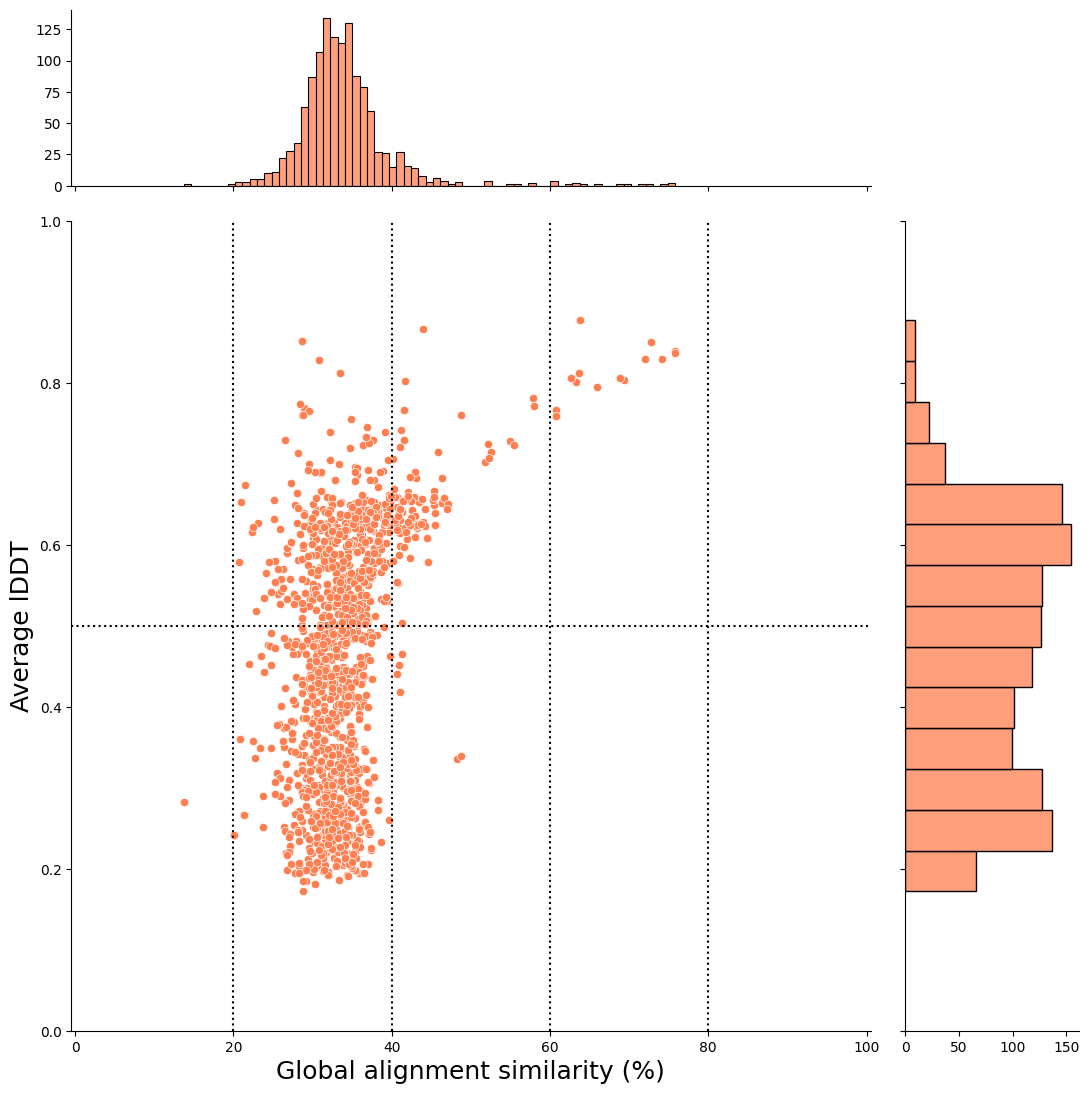

In [11]:
foldseek_filter_viz2 = join_foldseek.to_pandas()

sns.jointplot(
    data=foldseek_filter_viz2,
    x="Similarity_percent_needle",
    y="lddt",
    color="coral",
    height=11,
    ratio=4,
    marginal_ticks=True
)

plt.xlim(-0.5,100.5)
plt.ylim(0,1)
plt.xlabel("Global alignment similarity (%)", fontsize=18)
plt.ylabel("Average lDDT", fontsize=18) # see foldseek github https://github.com/steineggerlab/foldseek?tab=readme-ov-file#output-search
plt.axvline(x=20, color="black", linestyle=":")
plt.axvline(x=40, color="black", linestyle=":")
plt.axvline(x=60, color="black", linestyle=":")
plt.axvline(x=80, color="black", linestyle=":")
plt.axhline(y=0.5, color="black", linestyle=":")

plt.savefig(
    "foldseek_result_similarity_percent_needle_lddt_all.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

&nbsp;

&nbsp;

&nbsp;

&nbsp;

## Create Scatter Plot for all hits (x-axis: Similarity_percent_water) Local Alignment

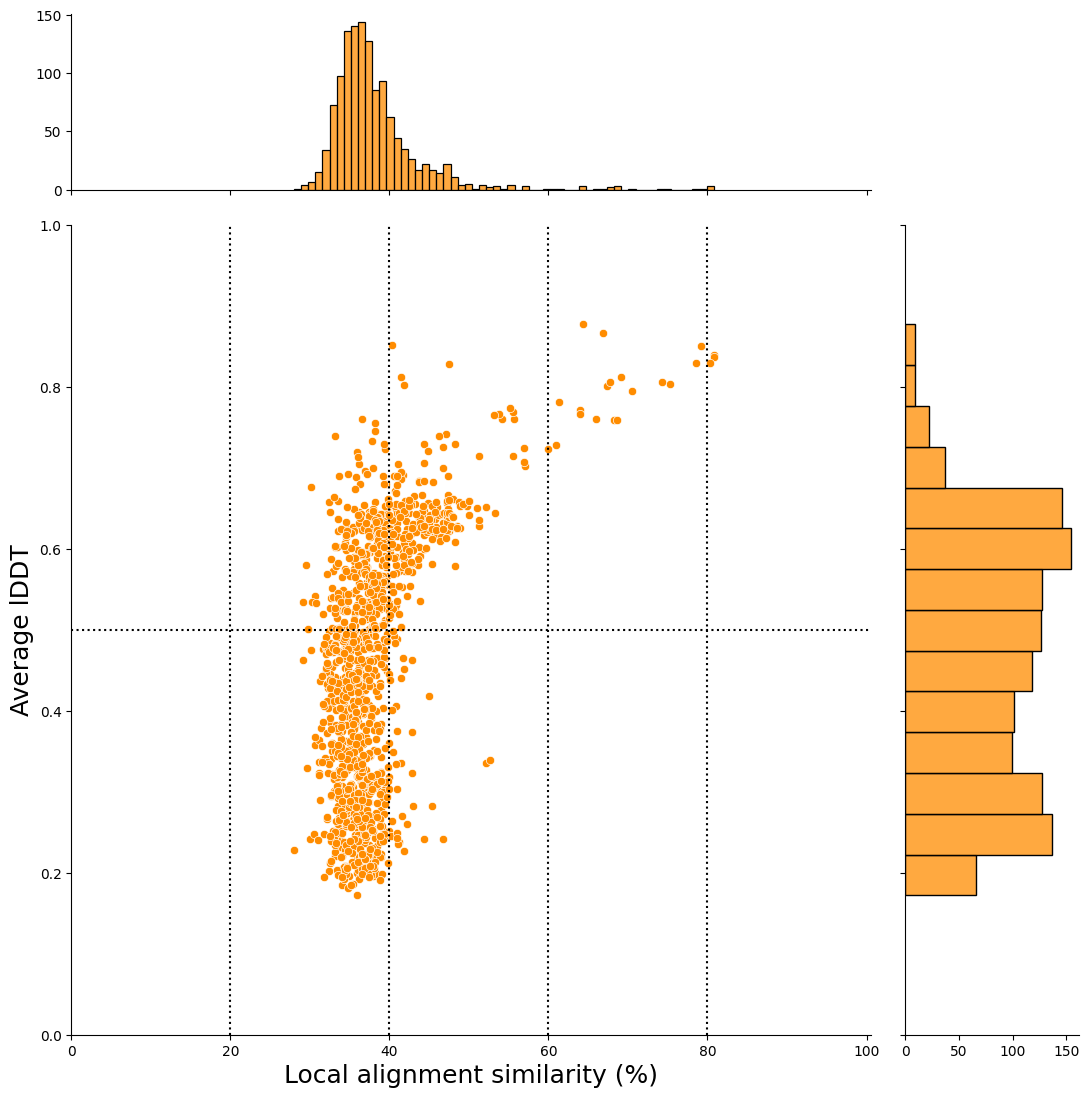

In [12]:
foldseek_filter_viz2 = join_foldseek.to_pandas()

sns.jointplot(
    data=foldseek_filter_viz2,
    x="Similarity_percent_water", # local alignment similarity
    y="lddt",
    color="darkorange",
    height=11,
    ratio=4,
    marginal_ticks=True
)

plt.xlim(0,100.5)
plt.ylim(0,1)
plt.xlabel("Local alignment similarity (%)", fontsize=18)
plt.ylabel("Average lDDT", fontsize=18) # see foldseek github https://github.com/steineggerlab/foldseek?tab=readme-ov-file#output-search
plt.axvline(x=20, color="black", linestyle=":")
plt.axvline(x=40, color="black", linestyle=":")
plt.axvline(x=60, color="black", linestyle=":")
plt.axvline(x=80, color="black", linestyle=":")
plt.axhline(y=0.5, color="black", linestyle=":")

plt.savefig(
    "foldseek_result_similarity_percent_water_lddt_all.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

&nbsp;

&nbsp;

&nbsp;

&nbsp;

## (6) Counting foldseek hits in Gene level

In [13]:
all_gene_list = pl.read_csv(
    query_gene_list_tsv_path,
    separator='\t'
).select(
    "From"
).unique()

hit_count = all_gene_list.join(
    join_foldseek,
    on="From",
    how="left",
    coalesce=True
).group_by("From", maintain_order=True).agg(
    (pl.col("foldseek hit").count().alias("target hit count (gene level vs uniprot accession)")),
    (pl.col("foldseek hit").is_null().all().alias("foldseek no hit"))
).sort(
    ["target hit count (gene level vs uniprot accession)"], descending=True
)

hit_count.write_csv(
    "foldseek_result_gene_level_hit_count_all.tsv",
    separator='\t'
)

display(hit_count)

From,target hit count (gene level vs uniprot accession),foldseek no hit
str,u32,bool
"""Solyc06g034200.1""",176,false
"""Solyc06g072800.3""",147,false
"""Solyc04g012180.3""",125,false
"""Solyc10g006890.3""",105,false
"""Solyc05g055100.2""",86,false
…,…,…
"""Solyc09g011410.3""",0,true
"""Solyc04g051077.1""",0,true
"""Solyc03g096370.3""",0,true


&nbsp;

&nbsp;

&nbsp;

# Caution:

- The filtering steps that are executed below can be changed freely.

&nbsp;

## (7) Filtering Condition1

- alignment coverage `>= 0.5`

In [14]:
condition1 = join_foldseek.filter(
        (pl.col("qcov") >= 0.5) &
        (pl.col("tcov") >= 0.5)
    ).sort(
        by=["From", "foldseek hit", "UniProt Accession"], # sort by From, foldseek hit, UniProt Accession
        descending=[False, False, False]
    )

condition1_rm = condition1.filter(
        (pl.col("qcov") < 0.5) |
        (pl.col("tcov") < 0.5)
    )

print(condition1.group_by(["From"], maintain_order=True).n_unique())
display(condition1)

shape: (41, 52)
┌────────────┬────────────┬────────────┬────────┬───┬────────────┬────────────┬───────────┬────────┐
│ From       ┆ UniProt    ┆ foldseek   ┆ evalue ┆ … ┆ Score_need ┆ Gap_penalt ┆ Extend_pe ┆ Matrix │
│ ---        ┆ Accession  ┆ hit        ┆ ---    ┆   ┆ le         ┆ y          ┆ nalty     ┆ ---    │
│ str        ┆ ---        ┆ ---        ┆ u32    ┆   ┆ ---        ┆ ---        ┆ ---       ┆ u32    │
│            ┆ u32        ┆ u32        ┆        ┆   ┆ u32        ┆ u32        ┆ u32       ┆        │
╞════════════╪════════════╪════════════╪════════╪═══╪════════════╪════════════╪═══════════╪════════╡
│ Solyc00g00 ┆ 1          ┆ 1          ┆ 1      ┆ … ┆ 1          ┆ 1          ┆ 1         ┆ 1      │
│ 8030.1     ┆            ┆            ┆        ┆   ┆            ┆            ┆           ┆        │
│ Solyc00g05 ┆ 1          ┆ 35         ┆ 33     ┆ … ┆ 35         ┆ 1          ┆ 1         ┆ 1      │
│ 0130.1     ┆            ┆            ┆        ┆   ┆            ┆         

From,UniProt Accession,foldseek hit,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,qcov,tcov,lddt,qtmscore,ttmscore,alntmscore,rmsd,qaln,taln,mismatch,lddtfull,Align_Length_water,Align_Length_needle,Identity_water,Identity_needle,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Gaps_water,Gaps_needle,Gaps_percent_water,Gaps_percent_needle,Shortest_Identity_water,Shortest_Identity_needle,Longest_Identity_water,Longest_Identity_needle,Shortest_Similarity_water,Shortest_Similarity_needle,Longest_Similarity_water,Longest_Similarity_needle,Score_water,Score_needle,Gap_penalty,Extend_penalty,Matrix
str,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,str,str,i64,str,i64,i64,str,str,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""Solyc00g008030.1""","""A0A494G8H9""","""A8MUL3""",0.2401,0.057,7,3.1,0.031,4,25,110,125,9,94,147,127,0.688,0.585,0.6768,0.271,0.2354,0.3711,3.941,"""I-AHIVGRHQALHVLIIHGKHTRSENVECG…","""PG-TSLTHALGAWRGRERAQAATSLLASSA…",41,"""0.221,0.361,0.603,0.597,0.611,…",159,176,"""26/159""","""26/176""",16.4,14.8,30.2,27.3,"""64/159""","""80/176""",40.3,45.5,17.69,17.69,27.37,27.08,32.65,32.65,50.53,50.0,120.0,118.0,10.0,0.5,"""EBLOSUM30"""
"""Solyc00g050130.1""","""A0A494G9G7""","""O60656""",0.6704,0.941,42,9.9,0.099,52,1,460,460,15,465,530,521,1.0,0.851,0.5536,0.7294,0.6405,0.7442,4.056,"""MA-IDNSSVLNEVTVAMVPWPEHGHLNPLF…","""CLLLTCGFAEA-GKLLVVPMD-GSHWFTMR…",338,"""0.458,0.643,0.594,0.477,0.375,…",571,623,"""117/571""","""115/623""",20.5,18.5,36.3,33.1,"""199/571""","""256/623""",34.9,41.1,22.08,21.7,31.45,31.34,39.06,38.87,55.65,56.13,425.0,421.0,10.0,0.5,"""EBLOSUM30"""
"""Solyc00g050130.1""","""A0A494G9G7""","""O75310""",0.6767,0.941,44,13.4,0.134,70,1,460,460,12,470,529,526,1.0,0.868,0.5545,0.7355,0.6474,0.7385,4.015,"""MA-ID-NSSVLNEVTVAMVPWPEHGHLNPL…","""IHLSCYFSSGSC-GKVLVWAAE-YSHWMNM…",323,"""0.417,0.786,0.656,0.364,0.417,…",563,597,"""111/563""","""111/597""",19.7,18.6,38.9,36.7,"""173/563""","""205/597""",30.7,34.3,20.98,20.98,28.46,28.32,41.4,41.4,56.15,55.87,492.5,491.5,10.0,0.5,"""EBLOSUM30"""
"""Solyc00g050130.1""","""A0A494G9G7""","""O75795""",0.6787,0.949,42,13.3,0.133,70,1,460,460,12,471,530,526,1.0,0.868,0.5679,0.7383,0.6481,0.7398,4.046,"""MA--IDNSSVLNEVTVAMVPWPEHGHLNPL…","""MQLSCYFSSGSC-GKVLVWPTE-YSHWINM…",324,"""0.625,0.857,0.750,0.568,0.444,…",555,609,"""109/555""","""111/609""",19.6,18.2,37.8,36.3,"""191/555""","""228/609""",34.4,37.4,20.57,20.94,29.95,29.13,39.62,41.7,57.69,58.01,495.5,488.0,10.0,0.5,"""EBLOSUM30"""
"""Solyc00g050130.1""","""A0A494G9G7""","""P06133""",0.6771,0.941,44,14.6,0.146,77,1,460,460,12,470,528,526,1.0,0.869,0.559,0.7355,0.6479,0.7384,4.033,"""MA-ID-NSSVLNEVTVAMVPWPEHGHLNPL…","""IQLSCYFSSGSC-GKVLVWPT-EFSHWMNI…",316,"""0.417,0.750,0.594,0.364,0.403,…",527,594,"""108/527""","""113/594""",20.5,19.0,39.5,37.4,"""157/527""","""200/594""",29.8,33.7,20.45,21.4,29.19,28.68,39.39,42.05,56.22,56.35,493.5,488.5,10.0,0.5,"""EBLOSUM30"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Solyc12g036793.1""","""A0A3Q7J846""","""Q9BYS8""",0.5296,0.505,25,9.5,0.095,43,9,392,396,61,370,371,450,0.97,0.836,0.5261,0.5278,0.56,0.6594,3.864,"""V----------------------------A…","""AVYCKNGFIDTSVRLLDKIERNTLTRQSSL…",201,"""0.008,0.100,0.120,0.083,0.152,…",393,464,"""93/393""","""94/464""",23.7,20.3,40.5,36.2,"""116/393""","""161/464""",29.5,34.7,23.48,23.74,33.57,31.02,40.15,42.42,57.4,55.45,335.5,326.5,10.0,0.5,"""EBLOSUM30"""
"""Solyc12g036793.1""","""A0A3Q7J846""","""Q9BZR6""",0.5144,0.632,36,7.6,0.076,36,23,388,396,21,392,473,469,0.924,0.786,0.5376,0.5705,0.4856,0.613,4.226,"""SNSHLQRLDLSSNNFSNSHIPPEFSKF-SR…","""WQVAAP-C-----------PGACVCYNE-P…",233,"""0.147,0.172,0.266,0.367,0.281,…",478,532,"""88/478""","""89/532""",18.4,16.7,34.3,32.1,"""158/478""","""195/532""",33.1,36.7,18.6,18.82

&nbsp;

&nbsp;

&nbsp;

&nbsp;

## (8) Filtering Condition2

- If there are hits with the same target for the same gene-derived UniProt ID, the one with the highest qcov is selected, and if the qcov is the same, the one with the highest lDDT is selected.
- **Note that in this study, we leave the states with the same foldseek hit even if the rice genes are different.**

In [15]:
condition2 = condition1.sort(
    by=["qcov", "lddt"],
    descending=[True, True]
).group_by(
    ["From", "foldseek hit"],
    maintain_order=True
).agg(
    pl.all().first()
).sort(
    by=["From", "UniProt Accession", "foldseek hit"],
    descending=[False, False, False]
).select(
    "From",
    "UniProt Accession",
    "foldseek hit",
    "evalue",
    "prob",
    "gapopen",
    "pident",
    "fident",
    "nident",
    "qstart",
    "qend",
    "qlen",
    "tstart",
    "tend",
    "tlen",
    "alnlen",
    "qcov",
    "tcov",
    "lddt",
    "qtmscore",
    "ttmscore",
    "alntmscore",
    "rmsd",
    "mismatch",
    "Align_Length_water",
    "Align_Length_needle",
    "Identity_water",
    "Identity_needle",
    "Identity_percent_water",
    "Identity_percent_needle",
    "Similarity_percent_water",
    "Similarity_percent_needle",
    "Shortest_Identity_water",
    "Shortest_Identity_needle",
    "Longest_Identity_water",
    "Longest_Identity_needle",
    "Shortest_Similarity_water",
    "Shortest_Similarity_needle",
    "Longest_Similarity_water",
    "Longest_Similarity_needle",
    "Gaps_water",
    "Gaps_percent_water",
    "Gaps_needle",
    "Gaps_percent_needle",
    "Score_water",
    "Score_needle",
    "Gap_penalty",
    "Extend_penalty",
    "Matrix"
)

display(condition2)

From,UniProt Accession,foldseek hit,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,qcov,tcov,lddt,qtmscore,ttmscore,alntmscore,rmsd,mismatch,Align_Length_water,Align_Length_needle,Identity_water,Identity_needle,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Shortest_Identity_water,Shortest_Identity_needle,Longest_Identity_water,Longest_Identity_needle,Shortest_Similarity_water,Shortest_Similarity_needle,Longest_Similarity_water,Longest_Similarity_needle,Gaps_water,Gaps_percent_water,Gaps_needle,Gaps_percent_needle,Score_water,Score_needle,Gap_penalty,Extend_penalty,Matrix
str,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,str,f64,f64,f64,f64,f64,str
"""Solyc00g008030.1""","""A0A494G8H9""","""A8MUL3""",0.2401,0.057,7,3.1,0.031,4,25,110,125,9,94,147,127,0.688,0.585,0.6768,0.271,0.2354,0.3711,3.941,41,159,176,"""26/159""","""26/176""",16.4,14.8,30.2,27.3,17.69,17.69,27.37,27.08,32.65,32.65,50.53,50.0,"""64/159""",40.3,"""80/176""",45.5,120.0,118.0,10.0,0.5,"""EBLOSUM30"""
"""Solyc00g050130.1""","""A0A494G9G7""","""O60656""",0.6704,0.941,42,9.9,0.099,52,1,460,460,15,465,530,521,1.0,0.851,0.5536,0.7294,0.6405,0.7442,4.056,338,571,623,"""117/571""","""115/623""",20.5,18.5,36.3,33.1,22.08,21.7,31.45,31.34,39.06,38.87,55.65,56.13,"""199/571""",34.9,"""256/623""",41.1,425.0,421.0,10.0,0.5,"""EBLOSUM30"""
"""Solyc00g050130.1""","""A0A494G9G7""","""O75310""",0.6767,0.941,44,13.4,0.134,70,1,460,460,12,470,529,526,1.0,0.868,0.5545,0.7355,0.6474,0.7385,4.015,323,563,597,"""111/563""","""111/597""",19.7,18.6,38.9,36.7,20.98,20.98,28.46,28.32,41.4,41.4,56.15,55.87,"""173/563""",30.7,"""205/597""",34.3,492.5,491.5,10.0,0.5,"""EBLOSUM30"""
"""Solyc00g050130.1""","""A0A494G9G7""","""O75795""",0.6787,0.949,42,13.3,0.133,70,1,460,460,12,471,530,526,1.0,0.868,0.5679,0.7383,0.6481,0.7398,4.046,324,555,609,"""109/555""","""111/609""",19.6,18.2,37.8,36.3,20.57,20.94,29.95,29.13,39.62,41.7,57.69,58.01,"""191/555""",34.4,"""228/609""",37.4,495.5,488.0,10.0,0.5,"""EBLOSUM30"""
"""Solyc00g050130.1""","""A0A494G9G7""","""P06133""",0.6771,0.941,44,14.6,0.146,77,1,460,460,12,470,528,526,1.0,0.869,0.559,0.7355,0.6479,0.7384,4.033,316,527,594,"""108/527""","""113/594""",20.5,19.0,39.5,37.4,20.45,21.4,29.19,28.68,39.39,42.05,56.22,56.35,"""157/527""",29.8,"""200/594""",33.7,493.5,488.5,10.0,0.5,"""EBLOSUM30"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Solyc12g036793.1""","""A0A3Q7J846""","""Q9BYS8""",0.5296,0.505,25,9.5,0.095,43,9,392,396,61,370,371,450,0.97,0.836,0.5261,0.5278,0.56,0.6594,3.864,201,393,464,"""93/393""","""94/464""",23.7,20.3,40.5,36.2,23.48,23.74,33.57,31.02,40.15,42.42,57.4,55.45,"""116/393""",29.5,"""161/464""",34.7,335.5,326.5,10.0,0.5,"""EBLOSUM30"""
"""Solyc12g036793.1""","""A0A3Q7J846""","""Q9BZR6""",0.5144,0.632,36,7.6,0.076,36,23,388,396,21,392,473,469,0.924,0.786,0.5376,0.5705,0.4856,0.613,4.226,233,478,532,"""88/478""","""89/532""",18.4,16.7,34.3,32.1,18.6,18.82,27.5,26.41,34.67,36.15,51.25,50.74,"""158/478""",33.1,"""195/532""",36.7,335.0,328.0,10.0,0.5,"""EBLOSUM30"""
"""Solyc12g036793.1""","""A0A3Q7J846""","""Q9GZU5""",0.5847,0.837,31,8.1,0.081,40,1,387,396,18,426,476,491,0.977,0.859,0.5497,0.6509,0.5514,0.6659,3.813,265,429,569,"""96/429""","""96/569""",22.4,16.9,40.3,30.6,20.17,20.17,32.32,31.68,36.34,36.55,58.25,57.43,"""132/429""",30.8,"""266/569""",46.7,364.5,361.5,10.0,0.5,"""EBLOSUM30"""


&nbsp;

&nbsp;

&nbsp;

&nbsp;

## (9) Filtering Condition3

- Select hits that can be converted to Ensembl gene id and HGNC Gene nomenclature with TogoID API
- https://togoid.dbcls.jp/

In [16]:
togoid_convert = pl.read_csv(
    togoid_convert_tsv_path,
    separator='\t'
).rename(
    {
        "uniprot_id" : "foldseek hit"
    }
).filter(
    pl.col("ensembl_gene_id").is_not_null() &
    pl.col("hgnc_symbol_id").is_not_null() # add HGNC Gene nomenclature information filtering condition
).sort(
    by=["foldseek hit"],
    descending=[False]
)

display(togoid_convert)

foldseek hit,ensembl_protein_id,ensembl_transcript_id,ensembl_gene_id,hgnc_id,hgnc_symbol_id
str,str,str,str,i64,str
"""A0A1W2PR19""","""ENSP00000492273""","""ENST00000621179""","""ENSG00000276950""",26930,"""GSTT4"""
"""A0A1W2PRG0""","""ENSP00000492227""","""ENST00000625476""","""ENSG00000281310""",33606,"""GSTTP2"""
"""A0A3B3IS91""","""ENSP00000516626""","""ENST00000706918""","""ENSG00000291307""",56246,"""POLGARF"""
"""A0PJZ3""","""ENSP00000374268""","""ENST00000389617""","""ENSG00000172986""",33383,"""GXYLT2"""
"""A1A4Y4""","""ENSP00000428220""","""ENST00000522154""","""ENSG00000237693""",29597,"""IRGM"""
…,…,…,…,…,…
"""Q9Y6R7""","""ENSP00000487490""","""ENST00000628705""","""ENSG00000281123""",13572,"""FCGBP"""
"""Q9Y6W5""","""ENSP00000439883""","""ENST00000536657""","""ENSG00000158195""",12733,"""WASF2"""
"""Q9Y6W5""","""ENSP00000483313""","""ENST00000618852""","""ENSG00000158195""",12733,"""WASF2"""


In [17]:
condition3 = condition2.join(
    togoid_convert,
    on="foldseek hit",
    how="left",
    coalesce=True
).drop(
    [
        "ensembl_transcript_id",
        "hgnc_id"
    ]
).filter( 
    pl.col("ensembl_gene_id").is_not_null() &
    pl.col("hgnc_symbol_id").is_not_null() # add HGNC Gene nomenclature information filtering condition
).select(
    [
        "From",
        "UniProt Accession",
        "foldseek hit",
        "ensembl_protein_id",
        "ensembl_gene_id",
        "hgnc_symbol_id",
        "evalue",
        "prob",
        "gapopen",
        "pident",
        "fident",
        "nident",
        "qstart",
        "qend",
        "qlen",
        "tstart",
        "tend",
        "tlen",
        "alnlen",
        "mismatch",
        "qcov",
        "tcov",
        "rmsd",
        "lddt",
        "qtmscore",
        "ttmscore",
        "alntmscore",
        "Align_Length_water",
        "Align_Length_needle",
        "Identity_water",
        "Identity_percent_water",
        "Identity_percent_needle",
        "Similarity_percent_water",
        "Similarity_percent_needle",
        "Shortest_Identity_water",
        "Shortest_Identity_needle",
        "Longest_Identity_water",
        "Longest_Identity_needle",
        "Shortest_Similarity_water",
        "Shortest_Similarity_needle",
        "Longest_Similarity_water",
        "Longest_Similarity_needle",
        "Gaps_water",
        "Gaps_percent_water",
        "Gaps_needle",
        "Gaps_percent_needle",
        "Score_water",
        "Score_needle",
        "Gap_penalty",
        "Extend_penalty",
        "Matrix"
    ]
).sort(
    by=["From", "foldseek hit", "UniProt Accession"], # sort by From, foldseek hit, UniProt Accession (change order)
    descending=[False, False, False]
)

condition3.write_csv(
    "foldseek_result_join_alignment_result_filter.tsv",
    separator='\t'
)

display(condition3)

From,UniProt Accession,foldseek hit,ensembl_protein_id,ensembl_gene_id,hgnc_symbol_id,evalue,prob,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,mismatch,qcov,tcov,rmsd,lddt,qtmscore,ttmscore,alntmscore,Align_Length_water,Align_Length_needle,Identity_water,Identity_percent_water,Identity_percent_needle,Similarity_percent_water,Similarity_percent_needle,Shortest_Identity_water,Shortest_Identity_needle,Longest_Identity_water,Longest_Identity_needle,Shortest_Similarity_water,Shortest_Similarity_needle,Longest_Similarity_water,Longest_Similarity_needle,Gaps_water,Gaps_percent_water,Gaps_needle,Gaps_percent_needle,Score_water,Score_needle,Gap_penalty,Extend_penalty,Matrix
str,str,str,str,str,str,f64,f64,i64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,i64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,str,f64,f64,f64,f64,f64,str
"""Solyc00g050130.1""","""A0A494G9G7""","""O60656""","""ENSP00000346768""","""ENSG00000241119""","""UGT1A9""",0.6704,0.941,42,9.9,0.099,52,1,460,460,15,465,530,521,338,1.0,0.851,4.056,0.5536,0.7294,0.6405,0.7442,571,623,"""117/571""",20.5,18.5,36.3,33.1,22.08,21.7,31.45,31.34,39.06,38.87,55.65,56.13,"""199/571""",34.9,"""256/623""",41.1,425.0,421.0,10.0,0.5,"""EBLOSUM30"""
"""Solyc00g050130.1""","""A0A494G9G7""","""O75310""","""ENSP00000387683""","""ENSG00000213759""","""UGT2B11""",0.6767,0.941,44,13.4,0.134,70,1,460,460,12,470,529,526,323,1.0,0.868,4.015,0.5545,0.7355,0.6474,0.7385,563,597,"""111/563""",19.7,18.6,38.9,36.7,20.98,20.98,28.46,28.32,41.4,41.4,56.15,55.87,"""173/563""",30.7,"""205/597""",34.3,492.5,491.5,10.0,0.5,"""EBLOSUM30"""
"""Solyc00g050130.1""","""A0A494G9G7""","""O75795""","""ENSP00000320401""","""ENSG00000197888""","""UGT2B17""",0.6787,0.949,42,13.3,0.133,70,1,460,460,12,471,530,526,324,1.0,0.868,4.046,0.5679,0.7383,0.6481,0.7398,555,609,"""109/555""",19.6,18.2,37.8,36.3,20.57,20.94,29.95,29.13,39.62,41.7,57.69,58.01,"""191/555""",34.4,"""228/609""",37.4,495.5,488.0,10.0,0.5,"""EBLOSUM30"""
"""Solyc00g050130.1""","""A0A494G9G7""","""P06133""","""ENSP00000305221""","""ENSG00000156096""","""UGT2B4""",0.6771,0.941,44,14.6,0.146,77,1,460,460,12,470,528,526,316,1.0,0.869,4.033,0.559,0.7355,0.6479,0.7384,527,594,"""108/527""",20.5,19.0,39.5,37.4,20.45,21.4,29.19,28.68,39.39,42.05,56.22,56.35,"""157/527""",29.8,"""200/594""",33.7,493.5,488.5,10.0,0.5,"""EBLOSUM30"""
"""Solyc00g050130.1""","""A0A494G9G7""","""P06133""","""ENSP00000421290""","""ENSG00000156096""","""UGT2B4""",0.6771,0.941,44,14.6,0.146,77,1,460,460,12,470,528,526,316,1.0,0.869,4.033,0.559,0.7355,0.6479,0.7384,527,594,"""108/527""",20.5,19.0,39.5,37.4,20.45,21.4,29.19,28.68,39.39,42.05,56.22,56.35,"""157/527""",29.8,"""200/594""",33.7,493.5,488.5,10.0,0.5,"""EBLOSUM30"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Solyc12g036793.1""","""A0A3Q7J846""","""Q9GZU5""","""ENSP00000340328""","""ENSG00000188937""","""NYX""",0.5847,0.837,31,8.1,0.081,40,1,387,396,18,426,476,491,265,0.977,0.859,3.813,0.5497,0.6509,0.5514,0.6659,429,569,"""96/429""",22.4,16.9,40.3,30.6,20.17,20.17,32.32,31.68,36.34,36.55,58.25,57.43,"""132/429""",30.8,"""266/569""",46.7,364.5,361.5,10.0,0.5,"""EBLOSUM30"""
"""Solyc12g036793.1""","""A0A3Q7J846""","""Q9GZU5""","""ENSP00000367465""","""ENSG00000188937""","""NYX""",0.5847,0.837,31,8.1,0.081,40,1,387,396,18,426,476,491,265,0.977,0.859,3.813,0.5497,0.6509,0.5514,0.6659,429,569,"""96/429""",22.4,16.9,40.3,30.6,20.17,20.17,32.32,31.68,36.34,36.55,58.25,57.43,"""132/429""",30.8,"""266/569""",46.7,364.5,361.5,10.0,0.5,"""EBLOSUM30"""
"""Solyc12g036793.1""","""A0A3Q7J846""","""Q9H756""","""ENSP00000369395""","""ENSG00000184434""","""LRRC19""",0.4189,0.214,26,8.4,0.084,38,72,381,396,26,364,370,449,162,0.783,0.916,4.326,0.4922,0.4187,0.4449,0.5204,445,456,"""97/445""",21.8,21.9,38.2,37.3,24.49,25.25,31.6,32.26,42.93,42.93,55.37,54.84,"""138/445""",31.0,"""146/456""",32.0,346.0,342.0,10.0,0.5,

&nbsp;

&nbsp;


In [18]:
foldseek_filter_viz = condition3.select(
    "From",
    "UniProt Accession",
    "foldseek hit",
    "qcov",
    "tcov",
    "rmsd",
    "lddt",
    "Identity_percent_needle",
    "Identity_percent_water",
    "Similarity_percent_needle",
    "Similarity_percent_water"
).unique(
    subset=["From", "UniProt Accession", "foldseek hit"]
).sort(
    by=["From"],
    descending=[False]
)

display(foldseek_filter_viz)

From,UniProt Accession,foldseek hit,qcov,tcov,rmsd,lddt,Identity_percent_needle,Identity_percent_water,Similarity_percent_needle,Similarity_percent_water
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64
"""Solyc00g050130.1""","""A0A494G9G7""","""P22309""",1.0,0.852,4.088,0.5634,18.9,20.8,35.9,38.9
"""Solyc00g050130.1""","""A0A494G9G7""","""Q9BY64""",1.0,0.866,3.987,0.561,18.4,19.3,35.6,37.7
"""Solyc00g050130.1""","""A0A494G9G7""","""P23368""",0.943,0.741,7.189,0.2713,15.6,18.9,28.3,34.3
"""Solyc00g050130.1""","""A0A494G9G7""","""Q96MS3""",0.978,0.991,4.509,0.445,16.3,17.8,29.8,32.5
"""Solyc00g050130.1""","""A0A494G9G7""","""Q3SY77""",1.0,0.872,3.889,0.563,19.0,21.0,34.5,38.8
…,…,…,…,…,…,…,…,…,…,…
"""Solyc12g036793.1""","""A0A3Q7J846""","""P51888""",0.859,0.819,3.729,0.5301,20.4,23.8,37.2,40.8
"""Solyc12g036793.1""","""A0A3Q7J846""","""Q96DD0""",0.811,0.794,4.199,0.5466,21.7,23.7,35.7,39.1
"""Solyc12g036793.1""","""A0A3Q7J846""","""Q96FV0""",0.965,0.623,4.7,0.4443,19.6,22.2,34.2,37.4


<Figure size 4000x4000 with 0 Axes>

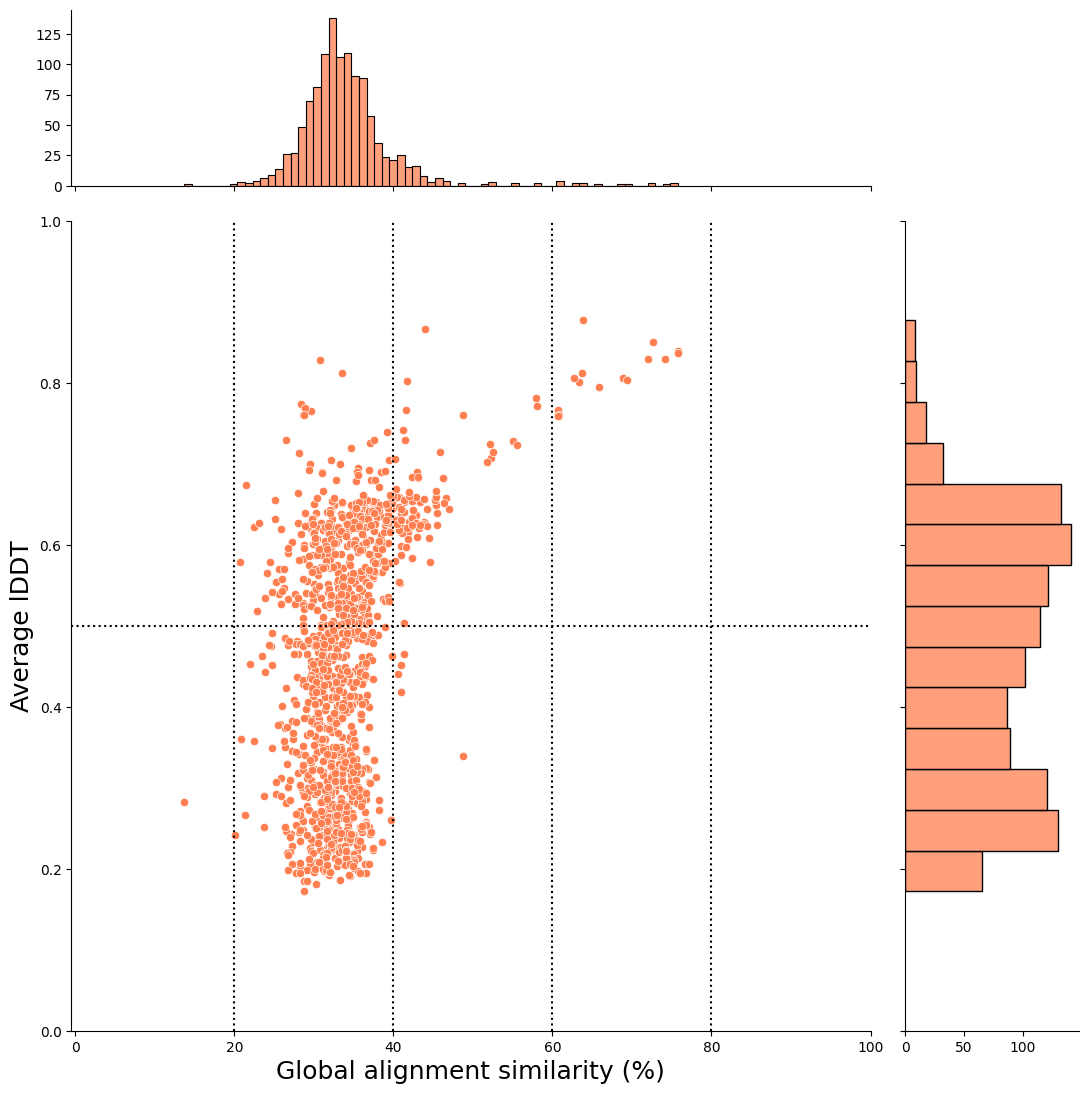

In [19]:
foldseek_filter_viz_pd = foldseek_filter_viz.to_pandas()

plt.figure(figsize=(8, 8), dpi=500)

sns.jointplot(
    data=foldseek_filter_viz_pd,
    x="Similarity_percent_needle",
    y="lddt",
    color="coral",
    height=11,
    ratio=4,
    marginal_ticks=True
)

plt.xlim(-0.5,100)
plt.ylim(0,1)
plt.xlabel("Global alignment similarity (%)", fontsize=18)
plt.ylabel("Average lDDT", fontsize=18) # see foldseek github https://github.com/steineggerlab/foldseek?tab=readme-ov-file#output-search
plt.axvline(x=20, color="black", linestyle=":")
plt.axvline(x=40, color="black", linestyle=":")
plt.axvline(x=60, color="black", linestyle=":")
plt.axvline(x=80, color="black", linestyle=":")
plt.axhline(y=0.5, color="black", linestyle=":")

plt.savefig(
    "foldseek_result_similarity_percent_needle_lddt_filter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 4000x4000 with 0 Axes>

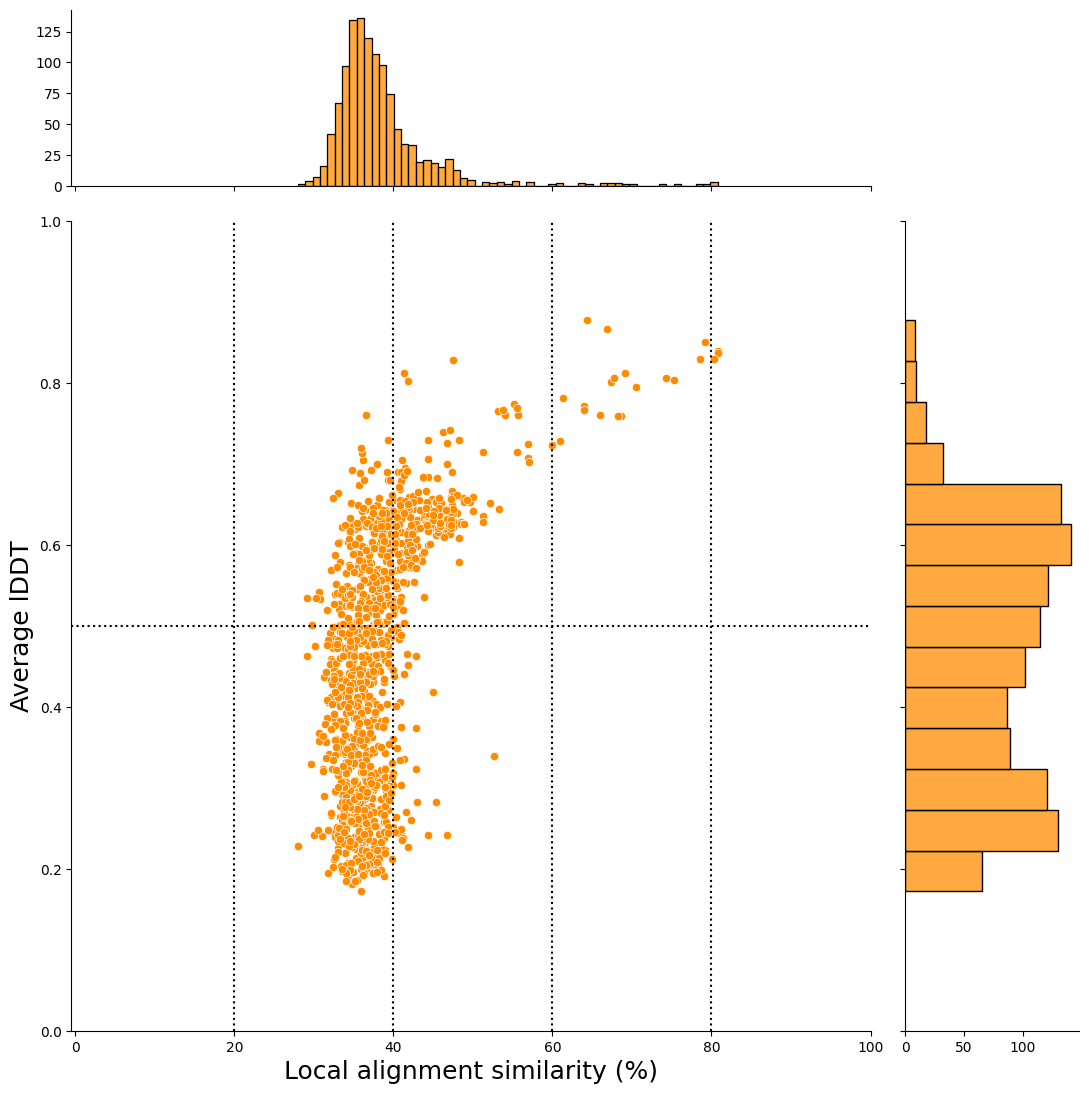

In [20]:
foldseek_filter_viz_pd = foldseek_filter_viz.to_pandas()

plt.figure(figsize=(8, 8), dpi=500)

sns.jointplot(
    data=foldseek_filter_viz_pd,
    x="Similarity_percent_water",
    y="lddt",
    color="darkorange",
    height=11,
    ratio=4,
    marginal_ticks=True
)

plt.xlim(-0.5,100)
plt.ylim(0,1)
plt.xlabel("Local alignment similarity (%)", fontsize=18)
plt.ylabel("Average lDDT", fontsize=18) # see foldseek github https://github.com/steineggerlab/foldseek?tab=readme-ov-file#output-search
plt.axvline(x=20, color="black", linestyle=":")
plt.axvline(x=40, color="black", linestyle=":")
plt.axvline(x=60, color="black", linestyle=":")
plt.axvline(x=80, color="black", linestyle=":")
plt.axhline(y=0.5, color="black", linestyle=":")

plt.savefig(
    "foldseek_result_similarity_percent_water_lddt_filter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

&nbsp;

&nbsp;
